# Build the Simple Parallel Workfrkflow for Cricket Batsman
""" parallel workflow - where we can run multiple tasks in parallel"""

"""
In parallel state we got this problem  - InvalidUpdateError: At key 'runs': Can receive only one value per step. Use an Annotated key to handle multiple values.
Which mean we can not return the full state from the function like calculate_sr/calculate_bpb/calculate_boundry_percent

And state contains these variables below and workflow running parallelly which may override the value
runs: int
balls: int
fours: int
sixes: int

#strike rate
sr: float
#balls per boundry
bpb: float
bountry_percent: float
summary: str

Only send the required state which is required in next step like in calculate_sr only sr:float is required in next step and we sending whole state.
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])/100
    state['sr'] = sr
    return state

same for other functions

"""

In [40]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [41]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    #strike rate
    sr: float
    #balls per boundry
    bpb: float
    bountry_percent: float
    summary: str


In [42]:
def calculate_sr(state: BatsmanState):
    sr = (state['runs']/state['balls'])*100
    
    return {'sr': sr}

In [43]:
def calculate_bpb(state: BatsmanState):
    bpb = state['balls']/(state['fours']+state['sixes'])
    
    return {'bpb': bpb}

In [44]:
def calculate_boundry_percent(state: BatsmanState):
    bountry_percent = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
    
    return {'bountry_percent': bountry_percent}

In [45]:
def summary(state: BatsmanState):
    summary = f"""
Strike Rate - {state['sr']} \n
Balls per Boundry - {state['bpb']} \n
Boundry Percent - {state['bountry_percent']}
"""
    
    
    return {'summary': summary}

In [46]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundry_percent', calculate_boundry_percent)
graph.add_node('summary', summary)


#edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundry_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundry_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()


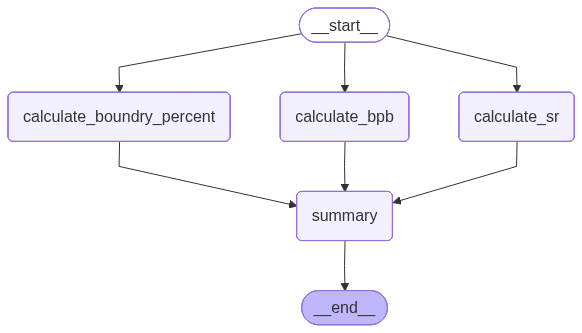

In [47]:
#to see graph
graph.compile()

In [48]:
initial_state = {
    'runs': 100,
    'balls':50,
    'fours': 6,
    'sixes': 4
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'bountry_percent': 48.0, 'summary': '\nStrike Rate - 200.0 \n\nBalls per Boundry - 5.0 \n\nBoundry Percent - 48.0\n'}
